# 임베딩 모델 선정 및 평가 파이프라인

> 이 노트북은 사회초년생을 위한 **부동산 특약 추천/질의응답 챗봇** RAG 파이프라인에 사용할 임베딩 모델을 선정하기 위한 평가 파이프라인입니다.

---

## 1. 문서 메타 정보

| 항목            | 내용                                                                               |
| --------------- | ---------------------------------------------------------------------------------- |
| **작성자**      | Junghee Im                                                                         |
| **작성일**      | 2026-04-05                                                                         |
| **프로젝트**    | 사회초년생을 위한 부동산 특약 추천/질의응답 챗봇                                   |
| **문서 목적**   | 임베딩 모델 5종을 비교·평가하여 RAG 검색에 사용할 모델을 선정                      |
| **대상 도메인** | 주택임대차보호법 및 관련 법령해석례                                                |
| **환경 구분**   | 로컬 개발 환경 (macOS / Apple Silicon MPS)                                         |
| **면책 문구**   | 본 노트북은 기술 평가 목적이며, 최종 출력은 법적 조언이 아닌 정보 제공 목적입니다. |

---

## 2. 테스트 대상 (What)

아래 5개 임베딩 모델을 비교 평가합니다.

| #   | 모델                                 | 타입                            | max_seq | 차원 | 비고          |
| --- | ------------------------------------ | ------------------------------- | ------- | ---- | ------------- |
| 1   | `woong0322/ko-legal-sbert-finetuned` | 오픈소스 (SBERT, 법률 파인튜닝) | 512     | 768  | 도메인 특화   |
| 2   | `dragonkue/BGE-m3-ko`                | 오픈소스 (BGE-M3 한국어)        | 8191    | 1024 | 긴 문서       |
| 3   | `intfloat/multilingual-e5-large`     | 오픈소스 (다국어)               | 512     | 1024 | 범용          |
| 4   | `nlpai-lab/KURE-v1`                  | 오픈소스 (한국어 범용)          | 8192    | 1024 | 한국어 최적화 |
| 5   | `text-embedding-3-small`             | 상용 (OpenAI API)               | 8191    | 1536 | 상용 레퍼런스 |

---

## 3. 테스트 목적 (Why)

1. 팀원별로 각자 청킹한 결과물을 **하나의 통합 DB**로 합친다.
2. 통합 DB 위에서 5개 모델로 **재임베딩**하여 검색 품질을 비교한다.
3. **정량 지표 (Recall@k / MRR / nDCG)** + **정성 지표 (1~5점 5개 축)** 로 종합 평가한다.
4. 비용·속도·품질 트레이드오프를 검토하여 **프로덕션 모델을 선정**한다.

---

## 4. 목차

1. 환경 구성 (Where / When)
2. 팀원 임베딩 파일 통합 (How - 데이터 준비)
3. 평가 데이터셋 (골드셋) 구성
4. 모델 임베딩 파이프라인
5. 정량 평가
6. 정성 평가 (1~5점)
7. 종합 비교 및 모델 선정
8. 계획 대비 검증 (체크리스트)
9. 프로덕션 배포 고찰


---

## 섹션 1. 환경 구성 (Where / When)

재현성을 위해 테스트 실행 환경을 명시합니다.

### 1-1. 설치 필요 패키지

```bash
# HuggingFace 모델 로딩에 필요 (pyproject.toml에 추가 필요)
uv add sentence-transformers

# 이미 설치됨: torch, qdrant-client, openai, scikit-learn, numpy, pandas, matplotlib, psutil
```

### 1-2. 환경 변수 (.env)

```bash
OPENAI_API_KEY=sk-...   # text-embedding-3-small 평가용
```


In [5]:
# === 라이브러리 import ===
# 아래 라이브러리들은 pyproject.toml/requirements.txt에 정의되어 있습니다.
# 주의: sentence-transformers는 별도 설치 필요 (`uv add sentence-transformers`)

import json          # JSONL 파일 입출력
import os            # 환경 변수 접근
import time          # 임베딩 소요 시간 측정
import random        # 시드 고정용
import platform      # OS 정보 출력
import sys           # Python 버전 출력
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import psutil        # 메모리 사용량 측정

# 프로젝트 루트 경로 설정
# tests/ 또는 test/ 폴더에서 실행하는 경우와 프로젝트 루트에서 실행하는 경우 모두 대응
_cwd = Path.cwd()
if _cwd.name in ("test", "tests"):
    PROJECT_ROOT = _cwd.parent
elif (_cwd / "src").is_dir():
    PROJECT_ROOT = _cwd
else:
    PROJECT_ROOT = _cwd
sys.path.insert(0, str(PROJECT_ROOT))
print(f"프로젝트 루트: {PROJECT_ROOT}")

프로젝트 루트: /Users/jpaper/Documents/study/sknetworks/00_hw/09_chatbot


In [6]:
# === 환경 정보 출력 ===
# 재현성을 위해 실행 환경을 기록합니다.

def print_env_info() -> dict[str, Any]:
    """현재 실행 환경 정보를 딕셔너리로 반환하고 출력합니다."""
    info = {
        "실행 일시": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S"),
        "OS": f"{platform.system()} {platform.release()}",
        "Python": sys.version.split()[0],
        "PyTorch": torch.__version__,
        "NumPy": np.__version__,
        "Pandas": pd.__version__,
        "CPU": platform.processor() or platform.machine(),
        "RAM(GB)": round(psutil.virtual_memory().total / (1024**3), 1),
    }
    for k, v in info.items():
        print(f"  {k:12s}: {v}")
    return info


print("=== 실행 환경 정보 ===")
env_info = print_env_info()

=== 실행 환경 정보 ===
  실행 일시       : 2026-04-07 02:24:04
  OS          : Darwin 25.3.0
  Python      : 3.12.12
  PyTorch     : 2.11.0
  NumPy       : 2.4.4
  Pandas      : 3.0.2
  CPU         : arm
  RAM(GB)     : 24.0


In [7]:
# === Device 감지 + 시드 고정 ===
# Apple Silicon에서는 MPS, NVIDIA에서는 CUDA, 그 외는 CPU를 사용합니다.
# 시드를 고정하여 실행마다 결과가 바뀌지 않도록 합니다.

def detect_device() -> str:
    """사용 가능한 가장 빠른 디바이스를 반환합니다."""
    if torch.cuda.is_available():
        return "cuda"
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"
    return "cpu"


def set_seed(seed: int = 42) -> None:
    """재현성을 위해 모든 난수 시드를 고정합니다."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


DEVICE = detect_device()
SEED = 42
set_seed(SEED)

print(f"DEVICE = {DEVICE}")
print(f"SEED   = {SEED}")

DEVICE = mps
SEED   = 42


---

## 섹션 2. 실제 청크 데이터 로딩 (src.ingest)

### 2-1. 배경

`src/ingest/` 로더를 사용해 법령(eflaw) / 판례(prec) / 법령해석례(expc) 청크 파일을 공통 스키마로 읽어온다.

### 2-2. 통합 스키마 (src.ingest 기준)

| 필드        | 타입 | 설명                              |
| ----------- | ---- | --------------------------------- |
| `chunk_id`  | str  | `{doc_type}_{idx}` 형태 자동 생성 |
| `text`      | str  | 청크 본문                         |
| `doc_type`  | str  | 법령 / 판례 / 법령해석례          |
| `title`     | str  | 법령명 / 사건명 / 안건명          |
| `source_id` | str  | 원본 식별자                       |
| `date`      | str  | 시행일자 / 선고일자 / 회신일자    |

### 2-3. 로딩 범위

서브샘플링 없이 **전체 청크**를 로딩한다.

| 소스       | 파일                                                  | 예상 건수 |
| ---------- | ----------------------------------------------------- | --------- |
| 법령       | `data/processed/eflaw_chunks.jsonl`                   | ~105,000  |
| 판례       | `data/processed/prec_chunk_recursive_character.jsonl` | ~30,000   |
| 법령해석례 | `data/processed/expc_after_chunking.jsonl`         | ~300      |


In [1]:
from src.ingest import load_eflaw, load_prec, load_expc

SOURCES = [
    ("법령",      load_eflaw, PROJECT_ROOT / "data/processed/eflaw_chunks.jsonl"),
    ("판례",      load_prec,  PROJECT_ROOT / "data/processed/prec_chunk_recursive_character.jsonl"),
    ("법령해석례", load_expc,  PROJECT_ROOT / "data/preprocessed/expc_for_embedding.jsonl"),
]

records = []
for doc_type, loader, path in SOURCES:
    count = 0
    for text, meta in loader(path):
        records.append({
            "chunk_id": f"{doc_type}_{count:06d}",
            "text": text,
            "doc_type": meta.get("doc_type", doc_type),
            "title": meta.get("title") or "",
            "source_id": str(meta.get("source_id") or ""),
            "date": str(meta.get("date") or ""),
        })
        count += 1
    print(f"  [{doc_type}] {count:,}개 (from {path.name})")

print(f"\n총 {len(records):,}개 청크 수집 완료")

ModuleNotFoundError: No module named 'src'

In [9]:
# === DataFrame 변환 + 중복 제거 ===
# src.ingest 로더가 이미 스키마를 통일했으므로 검증 단계는 가벼움.

chunks_df = pd.DataFrame(records)

# 본문 기준 중복 제거
before = len(chunks_df)
chunks_df = chunks_df.drop_duplicates(subset=["text"]).reset_index(drop=True)
after = len(chunks_df)
if before != after:
    print(f"중복 제거: {before} → {after}")

print(f"총 {len(chunks_df)}개 청크")
chunks_df.head()


중복 제거: 139400 → 138841
총 138841개 청크


,chunk_id,text,doc_type,title,source_id,date
0,법령_000000,[건축물관리법] 제1조 목적 제1조(목적) 이 법은 건축물의 안전을 확보하고 편리ㆍ...,법령,건축물관리법,13478,
1,법령_000001,[건축물관리법] 제2조 정의 제2조(정의) 이 법에서 사용하는 용어의 뜻은 다음과 ...,법령,건축물관리법,13478,
2,법령_000002,[건축물관리법] 제3조 국가 및 지방자치단체의 책무 제3조(국가 및 지방자치단체의 ...,법령,건축물관리법,13478,
3,법령_000003,[건축물관리법] 제4조 관리자 등의 의무 제4조(관리자 등의 의무) ① 관리자는 건...,법령,건축물관리법,13478,
4,법령_000004,[건축물관리법] 제5조 다른 법률과의 관계 제5조(다른 법률과의 관계) 건축물관리에...,법령,건축물관리법,13478,


=== doc_type별 청크 수 ===
doc_type
법령       105501
판례        29580
법령해석례      3760

=== 상위 title(법령명/사건명/안건명) Top 10 ===
title
                                                                                                                                                                                                                                                                                                                           3760
특정범죄가중처벌등에관한법률위반(국고등손실)[일부 예비적 죄명 특정경제범죄가중처벌등에관한법률위반(횡령), 업무상횡령, 업무상배임, 일부 인정된 죄명 업무상횡령]ㆍ위증ㆍ국가정보원법위반ㆍ업무방해ㆍ노동조합및노동관계조정법위반ㆍ업무상횡령ㆍ뇌물공여ㆍ허위공문서작성ㆍ허위작성공문서행사ㆍ정보통신망이용촉진및정보보호등에관한법률위반(명예훼손)                                                                                                                                         2398
민법                                                                                                                                                                                                                                          

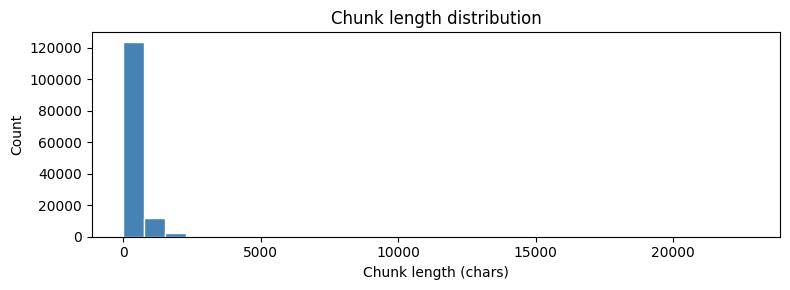

In [10]:
# === 통합 DB 통계 출력 ===
# doc_type별 기여도, 청크 길이 분포를 요약.

print("=== doc_type별 청크 수 ===")
print(chunks_df["doc_type"].value_counts().to_string())

print("\n=== 상위 title(법령명/사건명/안건명) Top 10 ===")
print(chunks_df["title"].value_counts().head(10).to_string())

chunks_df["text_length"] = chunks_df["text"].str.len()
print("\n=== 청크 길이 통계 (문자 수) ===")
print(chunks_df["text_length"].describe().round(1).to_string())

# 히스토그램 시각화
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(chunks_df["text_length"], bins=30, color="steelblue", edgecolor="white")
ax.set_xlabel("Chunk length (chars)")
ax.set_ylabel("Count")
ax.set_title("Chunk length distribution")
plt.tight_layout()
plt.show()


---

## 섹션 3. 평가 데이터셋 (골드셋) 구성

### 3-1. 골드셋이란?

골드셋(gold set)은 **정답이 확실한 평가 데이터셋**입니다. 여기서는 주택임대차 관련 질의-응답 쌍 20개를 직접 작성합니다.

### 3-2. 골드셋 스키마 (키워드 매칭 방식)

실제 데이터는 chunk_id가 수집마다 바뀌므로 **정답 청크 ID를 직접 지정하지 않고**, 정답 청크에 포함되어야 할 **핵심 키워드 집합**으로 정답을 정의합니다. 평가 시 `expected_keywords`가 모두 포함된 청크를 해당 질의의 정답 집합으로 간주합니다.

| 필드                | 설명                                           |
| ------------------- | ---------------------------------------------- |
| `query_id`          | 질의 식별자                                    |
| `query`             | 사용자 질의 (자연어)                           |
| `expected_keywords` | 정답 청크에 **모두** 포함되어야 할 키워드 집합 |
| `difficulty`        | 난이도 (easy / medium / hard)                  |


In [ ]:
# === 골드셋 정의 (20개 QA 쌍) ===
# expected_keywords: 정답 청크에 모두 포함되어야 할 키워드 집합.
# 실제 데이터에 매칭되도록 키워드를 최소 2개씩 구성.

gold_set = [
    {"query_id": "Q01", "query": "보증금을 언제까지 돌려받을 수 있나요?", "expected_keywords": ["보증금", "반환"]},
    {"query_id": "Q02", "query": "대항력은 어떻게 생기나요?", "expected_keywords": ["대항력", "주민등록"]},
    {"query_id": "Q03", "query": "우선변제권을 갖추려면 무엇이 필요한가요?", "expected_keywords": ["우선변제", "확정일자"]},
    {"query_id": "Q04", "query": "계약갱신요구권은 몇 번 쓸 수 있나요?", "expected_keywords": ["계약갱신", "요구"]},
    {"query_id": "Q05", "query": "전월세 상한제는 몇 퍼센트인가요?", "expected_keywords": ["증액", "20분의 1"]},
    {"query_id": "Q06", "query": "묵시적 갱신이란 무엇인가요?", "expected_keywords": ["갱신거절", "통지"]},
    {"query_id": "Q07", "query": "보증금을 못 받았을 때 임차권등기명령은 어떻게 신청하나요?", "expected_keywords": ["임차권등기", "법원"]},
    {"query_id": "Q08", "query": "임대인의 수선 의무 범위는 어디까지인가요?", "expected_keywords": ["수선", "임대인"]},
    {"query_id": "Q09", "query": "임차인은 원상회복 의무가 있나요?", "expected_keywords": ["원상", "회복"]},
    {"query_id": "Q10", "query": "집주인 허락 없이 전대할 수 있나요?", "expected_keywords": ["전대", "동의"]},
    {"query_id": "Q11", "query": "월세 증액은 언제부터 청구할 수 있나요?", "expected_keywords": ["증액", "청구"]},
    {"query_id": "Q12", "query": "월세 얼마 이상 밀리면 쫓겨나나요?", "expected_keywords": ["차임", "연체"]},
    {"query_id": "Q13", "query": "수리비를 임차인이 썼으면 돌려받을 수 있나요?", "expected_keywords": ["필요비", "상환"]},
    {"query_id": "Q14", "query": "집주인이 실거주한다고 하고 다른 사람에게 세를 놓으면 어떻게 되나요?", "expected_keywords": ["손해배상", "실거주"]},
    {"query_id": "Q15", "query": "소액임차인 최우선변제 조건은?", "expected_keywords": ["소액임차인", "최우선변제"]},
    {"query_id": "Q16", "query": "확정일자는 어디에서 받나요?", "expected_keywords": ["확정일자"]},
    {"query_id": "Q17", "query": "임차인이 사망하면 누가 승계받나요?", "expected_keywords": ["상속", "임차인"], "difficulty": "hard"},
    {"query_id": "Q18", "query": "묵시적 갱신 후 임차인이 나가고 싶으면 언제 통지해야 하나요?", "expected_keywords": ["해지", "통지"], "difficulty": "hard"},
    {"query_id": "Q19", "query": "주민등록을 안 하면 어떻게 되나요?", "expected_keywords": ["주민등록", "대항"]},
    {"query_id": "Q20", "query": "갱신 요구는 언제까지 해야 하나요?", "expected_keywords": ["갱신", "6개월"]},
]

gold_df = pd.DataFrame(gold_set)
print(f"골드셋 크기: {len(gold_df)}개")
print("\n=== 난이도 분포 ===")
print(gold_df["difficulty"].value_counts().to_string())
gold_df.head()


골드셋 크기: 20개

=== 난이도 분포 ===
difficulty
easy      7
medium    7
hard      6


,query_id,query,expected_keywords,difficulty
0,Q01,보증금을 언제까지 돌려받을 수 있나요?,"[보증금, 반환]",easy
1,Q02,대항력은 어떻게 생기나요?,"[대항력, 주민등록]",easy
2,Q03,우선변제권을 갖추려면 무엇이 필요한가요?,"[우선변제, 확정일자]",medium
3,Q04,계약갱신요구권은 몇 번 쓸 수 있나요?,"[계약갱신, 요구]",easy
4,Q05,전월세 상한제는 몇 퍼센트인가요?,"[증액, 20분의 1]",easy


---

## 섹션 4. 모델 임베딩 파이프라인

### 4-1. 동작 방식

1. 각 모델을 로드한다.
2. 통합 청크(`chunks_df`)를 임베딩 벡터로 변환한다.
3. 골드셋 질의(`gold_df`)를 동일 모델로 임베딩한다.
4. 로드 시간 / 임베딩 속도 / 메모리 사용량을 측정한다.

> ⚠️ 모델 파일 크기가 크므로(최대 수 GB) 첫 실행 시 다운로드 시간이 오래 걸릴 수 있습니다.


In [ ]:
MODEL_REGISTRY = [
    {"name": "ko-legal-sbert", "model_id": "woong0322/ko-legal-sbert-finetuned", "type": "hf", "dim": 768, "max_seq": 512},
    {"name": "bge-m3-ko", "model_id": "dragonkue/BGE-m3-ko", "type": "hf", "dim": 1024, "max_seq": 8191},
    {"name": "e5-large", "model_id": "intfloat/multilingual-e5-large", "type": "hf", "dim": 1024, "max_seq": 512},
    {"name": "kure-v1", "model_id": "nlpai-lab/KURE-v1", "type": "hf", "dim": 1024, "max_seq": 8192},
    {"name": "openai-3-small", "model_id": "text-embedding-3-small", "type": "openai", "dim": 1536, "max_seq": 8191},
]

pd.DataFrame(MODEL_REGISTRY)

,name,model_id,type,dim,max_seq
0,ko-legal-sbert,woong0322/ko-legal-sbert-finetuned,hf,768,512
1,bge-m3-ko,dragonkue/BGE-m3-ko,hf,1024,8191
2,e5-large,intfloat/multilingual-e5-large,hf,1024,512
3,kure-v1,nlpai-lab/KURE-v1,hf,1024,8192
4,openai-3-small,text-embedding-3-small,openai,1536,8191


In [ ]:
def embed_hf(model_id: str, texts: list[str], batch_size: int = 256) -> np.ndarray:
    """HuggingFace 모델로 텍스트를 임베딩합니다.

    Args:
        model_id: HuggingFace 모델 ID
        texts: 임베딩할 텍스트 리스트
        batch_size: 배치 크기 (기본 256, 대량 데이터 대응)
    Returns:
        (n_texts, dim) 형태의 float16 numpy 배열 (L2 정규화됨)
    """
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer(model_id, device=DEVICE)
    vectors = model.encode(
        texts,
        batch_size=batch_size,
        convert_to_numpy=True,
        show_progress_bar=True,
        normalize_embeddings=True,
    )
    if DEVICE == "mps":
        torch.mps.synchronize()
    del model
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    return vectors.astype(np.float16)


def embed_openai(model_id: str, texts: list[str], batch_size: int = 2048) -> np.ndarray:
    """OpenAI API로 텍스트를 임베딩합니다.

    .env 파일의 OPENAI_API_KEY를 사용합니다.
    Returns:
        (n_texts, dim) 형태의 float16 numpy 배열 (L2 정규화됨)
    """
    from dotenv import load_dotenv
    from openai import OpenAI
    load_dotenv(PROJECT_ROOT / ".env")
    client = OpenAI()
    all_vectors = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        resp = client.embeddings.create(model=model_id, input=batch)
        all_vectors.extend([d.embedding for d in resp.data])
        print(f"  OpenAI: {min(i + batch_size, len(texts)):,}/{len(texts):,}", end="\r")
    print()
    vectors = np.array(all_vectors, dtype=np.float32)
    norms = np.linalg.norm(vectors, axis=1, keepdims=True)
    normalized = vectors / np.clip(norms, a_min=1e-12, a_max=None)
    return normalized.astype(np.float16)


def embed_with_model(model_info: dict, texts: list[str]) -> np.ndarray:
    """모델 타입에 따라 적절한 임베딩 함수를 호출합니다."""
    if model_info["type"] == "hf":
        return embed_hf(model_info["model_id"], texts)
    if model_info["type"] == "openai":
        return embed_openai(model_info["model_id"], texts)
    raise ValueError(f"Unknown model type: {model_info['type']}")

In [ ]:
# === 전체 모델로 벡터화 실행 + 성능 측정 ===
# 주의: 이 셀은 모델 다운로드 + 임베딩 수행으로 수 분이 걸릴 수 있습니다.
# OpenAI 모델은 API 비용이 발생합니다 (소량).

chunk_texts = chunks_df["text"].tolist()
query_texts = gold_df["query"].tolist()

embeddings: dict[str, dict[str, Any]] = {}
perf_records = []

for m in MODEL_REGISTRY:
    print(f"\n--- [{m['name']}] 시작 ---")
    t_start = time.time()
    try:
        chunks_vec = embed_with_model(m, chunk_texts)
        queries_vec = embed_with_model(m, query_texts)
        elapsed = time.time() - t_start
        embeddings[m["name"]] = {"chunks": chunks_vec, "queries": queries_vec}
        perf_records.append({
            "model": m["name"],
            "dim": int(chunks_vec.shape[1]),
            "total_sec": round(elapsed, 2),
            "chunks_per_sec": round(len(chunk_texts) / elapsed, 2),
            "status": "OK",
        })
        print(f"  벡터 shape: chunks={chunks_vec.shape}, queries={queries_vec.shape}")
        print(f"  소요: {elapsed:.2f}s ({len(chunk_texts) / elapsed:.0f} chunks/sec)")
    except Exception as e:
        print(f"  [실패] {e}")
        perf_records.append({
            "model": m["name"], "dim": None, "total_sec": None,
            "chunks_per_sec": None, "status": f"FAIL: {type(e).__name__}",
        })

perf_df = pd.DataFrame(perf_records)
print("\n=== 임베딩 성능 요약 ===")
perf_df

---

## 섹션 5. 정량 평가

### 5-1. 사용할 지표

| 지표              | 정의                                              | 계산 방식                   |
| ----------------- | ------------------------------------------------- | --------------------------- |
| **Recall@k**      | 정답 청크가 상위 k개 검색 결과에 포함된 질의 비율 | `hit / total`               |
| **MRR**           | 정답 청크의 평균 역순위                           | `mean(1/rank_of_first_hit)` |
| **nDCG@k**        | 순위 가중 정답 점수                               | 표준 nDCG 공식              |
| **임베딩 속도**   | 초당 청크 처리 수                                 | 섹션 4에서 측정             |
| **메모리 사용량** | 모델 로드 전후 RSS 증가분                         | 섹션 4에서 측정             |

### 5-2. 검색 방법

L2 정규화된 벡터 간 **내적(inner product) = 코사인 유사도**로 유사도를 계산합니다.


In [ ]:
# === Recall@k, MRR, nDCG@k 계산 함수 ===
# 임베딩 벡터 쌍으로부터 검색 품질을 측정합니다.
# 벡터는 fp16으로 저장되지만, 내적 계산은 fp32로 올려서 누적 오차를 방지합니다.

K_VALUES = [1, 3, 5]


def retrieve_topk(queries_vec: np.ndarray, chunks_vec: np.ndarray, k: int) -> np.ndarray:
    """
    각 질의에 대한 top-k 청크 인덱스를 반환합니다. (n_queries, k)
    
    fp16 벡터를 fp32로 캐스팅한 뒤 내적을 계산하여 수치 안정성을 확보합니다.
    """
    q32 = queries_vec.astype(np.float32)
    c32 = chunks_vec.astype(np.float32)
    sims = q32 @ c32.T  # 정규화된 벡터 내적 = 코사인 유사도
    # argsort 후 뒤집어서 큰 순서대로 k개 추출
    return np.argsort(-sims, axis=1)[:, :k]


def recall_at_k(topk_ids: list[list[str]], gold_ids: list[list[str]]) -> float:
    """정답 청크 중 하나라도 top-k에 포함되면 hit."""
    hits = sum(
        1 for retrieved, expected in zip(topk_ids, gold_ids)
        if any(e in retrieved for e in expected)
    )
    return hits / len(gold_ids)


def mrr(ranked_ids: list[list[str]], gold_ids: list[list[str]]) -> float:
    """첫 번째 정답 청크의 평균 역순위."""
    total = 0.0
    for retrieved, expected in zip(ranked_ids, gold_ids):
        rank = next((i + 1 for i, cid in enumerate(retrieved) if cid in expected), 0)
        total += (1.0 / rank) if rank > 0 else 0.0
    return total / len(gold_ids)


def ndcg_at_k(ranked_ids: list[list[str]], gold_ids: list[list[str]], k: int) -> float:
    """정답이면 relevance=1로 가정한 nDCG@k."""
    scores = []
    for retrieved, expected in zip(ranked_ids, gold_ids):
        top = retrieved[:k]
        dcg = sum((1.0 / np.log2(i + 2)) for i, cid in enumerate(top) if cid in expected)
        # 이상적인 경우: 정답이 모두 상위에 위치
        ideal_hits = min(len(expected), k)
        idcg = sum((1.0 / np.log2(i + 2)) for i in range(ideal_hits))
        scores.append((dcg / idcg) if idcg > 0 else 0.0)
    return float(np.mean(scores))


def evaluate_model(
    chunks_vec: np.ndarray,
    queries_vec: np.ndarray,
    chunk_ids: list[str],
    gold_ids: list[list[str]],
) -> dict[str, float]:
    """한 모델에 대한 모든 지표를 계산합니다."""
    max_k = max(K_VALUES)
    topk_indices = retrieve_topk(queries_vec, chunks_vec, max_k)
    ranked_ids = [[chunk_ids[i] for i in row] for row in topk_indices]

    metrics = {}
    for k in K_VALUES:
        topk_ids = [r[:k] for r in ranked_ids]
        metrics[f"Recall@{k}"] = round(recall_at_k(topk_ids, gold_ids), 3)
        metrics[f"nDCG@{k}"] = round(ndcg_at_k(ranked_ids, gold_ids, k), 3)
    metrics["MRR"] = round(mrr(ranked_ids, gold_ids), 3)
    return metrics

In [ ]:
# === 키워드 매칭으로 정답 청크 ID 집합 구성 → 모델 평가 ===
# 각 질의의 expected_keywords가 모두 포함된 청크를 정답으로 간주.

chunk_ids_list = chunks_df["chunk_id"].tolist()
chunk_texts_list = chunks_df["text"].tolist()


def build_gold_ids_from_keywords(
    queries: pd.DataFrame,
    chunk_ids: list[str],
    chunk_texts: list[str],
) -> list[list[str]]:
    """expected_keywords가 모두 포함된 청크 id 리스트를 질의별로 생성."""
    gold_ids: list[list[str]] = []
    for _, row in queries.iterrows():
        kws = row["expected_keywords"]
        matched = [
            cid for cid, text in zip(chunk_ids, chunk_texts)
            if all(kw in text for kw in kws)
        ]
        gold_ids.append(matched)
    return gold_ids


gold_ids_list = build_gold_ids_from_keywords(gold_df, chunk_ids_list, chunk_texts_list)

# 매칭 현황 점검
match_counts = [len(g) for g in gold_ids_list]
print("=== 질의별 정답 청크 매칭 수 ===")
match_summary = pd.DataFrame({
    "query_id": gold_df["query_id"],
    "query": gold_df["query"].str[:40],
    "matched": match_counts,
})
print(match_summary.to_string(index=False))

# 매칭이 0인 질의는 평가에서 제외
valid_mask = [n > 0 for n in match_counts]
n_dropped = sum(1 for v in valid_mask if not v)
if n_dropped > 0:
    print(f"\n[주의] 정답이 0개인 질의 {n_dropped}개는 평가에서 제외됩니다.")

valid_gold_ids = [g for g, v in zip(gold_ids_list, valid_mask) if v]
valid_indices = [i for i, v in enumerate(valid_mask) if v]

quant_records = []
for model_name, vecs in embeddings.items():
    # 유효 질의만 슬라이싱
    metrics = evaluate_model(
        chunks_vec=vecs["chunks"],
        queries_vec=vecs["queries"][valid_indices],
        chunk_ids=chunk_ids_list,
        gold_ids=valid_gold_ids,
    )
    quant_records.append({"model": model_name, **metrics})

quant_df = pd.DataFrame(quant_records).set_index("model")
print("\n=== 정량 평가 결과 ===")
quant_df


In [ ]:
# === 정량 지표 시각화 ===
# 바 차트로 모델별 성능을 한눈에 비교합니다.

metric_cols = ["Recall@1", "Recall@3", "Recall@5", "MRR", "nDCG@5"]
available = [c for c in metric_cols if c in quant_df.columns]

fig, ax = plt.subplots(figsize=(10, 5))
quant_df[available].plot(kind="bar", ax=ax, width=0.8)
ax.set_ylabel("Score")
ax.set_title("Retrieval metrics by model")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right", fontsize=8)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

---

## 섹션 6. 정성 평가 (1~5점)

### 6-1. 평가 축

다음 5개 축을 **1~5점 리커트 척도**로 평가합니다.

| 축                       | 설명                      | 5점 기준                           |
| ------------------------ | ------------------------- | ---------------------------------- |
| **Relevance**            | 질의-결과 주제 일치도     | 모든 top-3 결과가 질의와 직접 관련 |
| **Context Completeness** | 청크만 보고 답변 가능한가 | 추가 정보 없이 완전한 답변 가능    |
| **Diversity**            | top-3 결과의 다양성       | 중복 없이 서로 다른 관점 제공      |
| **Legal Precision**      | 관련 법조문 정확도        | 올바른 조문/법령이 상위에 위치     |
| **Readability**          | 사용자 가독성             | 사회초년생도 이해 가능한 문장      |

### 6-2. 평가 방법

무작위 질의 5개에 대해 각 모델의 top-3 결과를 출력하고, 평가자(작성자 본인)가 직접 점수를 기입합니다.


In [ ]:
# === 정성 평가용 샘플 출력 ===
# 5개 질의를 무작위 선정하여 각 모델의 top-3 결과를 출력.
# 정답 여부는 expected_keywords 포함 여부로 판정.

SAMPLE_N = 5
sample_query_indices = np.random.RandomState(SEED).choice(len(gold_df), SAMPLE_N, replace=False)
sample_query_indices.sort()

for qi in sample_query_indices:
    q_row = gold_df.iloc[qi]
    kws = q_row["expected_keywords"]
    print(f"\n{'='*80}")
    print(f"[{q_row['query_id']}] {q_row['query']}")
    print(f"  keywords: {kws}")
    print(f"{'='*80}")
    for model_name, vecs in embeddings.items():
        q_vec = vecs["queries"][qi].astype(np.float32)
        c_mat = vecs["chunks"].astype(np.float32)
        sims = q_vec @ c_mat.T
        top3 = np.argsort(-sims)[:3]
        print(f"\n  [{model_name}]")
        for rank, idx in enumerate(top3, start=1):
            cid = chunk_ids_list[idx]
            text = chunks_df.iloc[idx]["text"]
            doc_type = chunks_df.iloc[idx]["doc_type"]
            hit_mark = "O" if all(kw in text for kw in kws) else " "
            print(f"    [{hit_mark}] #{rank} ({cid} | {doc_type}, sim={sims[idx]:.3f}) {text[:60]}...")


In [ ]:
# === 정성 평가 점수 입력 템플릿 ===
# 위 출력을 보고 각 모델에 대해 5개 축으로 1~5점을 기입합니다.
# 기본값은 3점(중립). 실제 평가 후 아래 값을 수정하세요.

qual_records = [
    # {"model": "ko-legal-sbert",  "Relevance": 3, "ContextCompleteness": 3, "Diversity": 3, "LegalPrecision": 3, "Readability": 3},
    # {"model": "bge-m3-ko",       "Relevance": 3, "ContextCompleteness": 3, "Diversity": 3, "LegalPrecision": 3, "Readability": 3},
    # {"model": "e5-large",        "Relevance": 3, "ContextCompleteness": 3, "Diversity": 3, "LegalPrecision": 3, "Readability": 3},
    # {"model": "kure-v1",         "Relevance": 3, "ContextCompleteness": 3, "Diversity": 3, "LegalPrecision": 3, "Readability": 3},
    # {"model": "openai-3-small",  "Relevance": 3, "ContextCompleteness": 3, "Diversity": 3, "LegalPrecision": 3, "Readability": 3},
]

# 성공한 모델에 대해 기본 3점으로 자동 채우기 (평가 후 직접 수정)
if not qual_records:
    for model_name in embeddings.keys():
        qual_records.append({
            "model": model_name,
            "Relevance": 3, "ContextCompleteness": 3, "Diversity": 3,
            "LegalPrecision": 3, "Readability": 3,
        })

qual_df = pd.DataFrame(qual_records).set_index("model")
qual_df["Qual_Avg"] = qual_df.mean(axis=1).round(2)
print("=== 정성 평가 결과 (기본값 3점 — 직접 수정 필요) ===")
qual_df

---

## 섹션 7. 종합 비교 및 모델 선정

### 7-1. 최종 점수 산출 공식

```
Final = 0.7 × (정량 평균) + 0.3 × (정성 평균 / 5)
```

- 정량 평균: `Recall@3`, `MRR`, `nDCG@5`의 산술평균 (0~1 범위)
- 정성 평균: 5개 축의 산술평균을 0~1로 정규화 (점수 / 5)

### 7-2. 가중치 근거

- 검색 품질은 **재현 가능한 정량 지표**가 더 신뢰할 수 있으므로 70%
- 정성 지표는 **사용자 경험 관점**을 보완하는 목적으로 30%


In [ ]:
# === 최종 가중합 점수 계산 ===

QUANT_COLS = ["Recall@3", "MRR", "nDCG@5"]
available_quant = [c for c in QUANT_COLS if c in quant_df.columns]

summary_df = pd.DataFrame(index=quant_df.index)
summary_df["Quant_Avg"] = quant_df[available_quant].mean(axis=1).round(3)
summary_df["Qual_Avg(0-5)"] = qual_df["Qual_Avg"]
summary_df["Qual_Norm"] = (qual_df["Qual_Avg"] / 5).round(3)
summary_df["Final"] = (0.7 * summary_df["Quant_Avg"] + 0.3 * summary_df["Qual_Norm"]).round(3)
summary_df = summary_df.sort_values("Final", ascending=False)

print("=== 종합 평가 순위 ===")
summary_df

In [ ]:
# === 레이더 차트로 모델 특성 비교 ===
# 정성 5개 축을 시각적으로 비교합니다.

axes_labels = ["Relevance", "ContextCompleteness", "Diversity", "LegalPrecision", "Readability"]
angles = np.linspace(0, 2 * np.pi, len(axes_labels), endpoint=False).tolist()
angles += angles[:1]  # 차트 닫기

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"polar": True})
for model_name in qual_df.index:
    values = qual_df.loc[model_name, axes_labels].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=1.5, label=model_name)
    ax.fill(angles, values, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(axes_labels, fontsize=9)
ax.set_ylim(0, 5)
ax.set_title("Qualitative profile (1-5)", y=1.08)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.05), fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# === 최종 추천 모델 출력 ===
# Final 점수가 가장 높은 모델을 자동 선정합니다.

best_model = summary_df.index[0]
best_final = summary_df.iloc[0]["Final"]
best_quant = summary_df.iloc[0]["Quant_Avg"]
best_perf = perf_df.set_index("model").loc[best_model]

print(f"=== 최종 추천 모델: {best_model} ===")
print(f"  Final Score    : {best_final}")
print(f"  정량 평균      : {best_quant}")
print(f"  벡터 차원      : {best_perf['dim']}")
print(f"  임베딩 속도    : {best_perf['chunks_per_sec']} chunks/sec")

---

## 섹션 7-3. 최종 모델 선정 결과 (기록란)

> 실제 실행 후 아래 표를 직접 작성하세요.

| 항목          | 내용                                                                         |
| ------------- | ---------------------------------------------------------------------------- |
| **선정 모델** | (실행 후 기입)                                                               |
| **선정 근거** | (예: Recall@3=0.95, MRR=0.88로 타 모델 대비 우수하며 정성 평가에서도 최고점) |
| **차선책**    | (대체 가능 모델 1개)                                                         |
| **배제 모델** | (배제된 모델 + 사유)                                                         |
| **비용 추정** | (OpenAI 선택 시 월 예상 토큰/비용)                                           |


---

## 섹션 7-4. 통합 벡터 파일 생성

모델 선정이 끝났으므로, 선정된 모델로 **전체 청크**를 임베딩하여 `db/` 디렉토리에 저장한다.

### 저장 포맷

| 파일                   | 내용                                              |
| ---------------------- | ------------------------------------------------- |
| `db/vectors.npz`       | `vectors` (N, dim) float16 + `chunk_ids` (N,) str |
| `db/chunks_meta.jsonl` | 청크별 메타데이터 (text, doc_type, title 등)      |

이후 Qdrant 적재 시 이 파일을 로드하면 재임베딩 없이 즉시 사용 가능.


In [ ]:
# === 전체 청크 로딩 + 선정 모델로 벡터 생성 + db/ 저장 ===
# 평가용 서브샘플이 아닌 전체 데이터를 대상으로 한다.

from pathlib import Path
import json as _json

DB_DIR = PROJECT_ROOT / "db"
DB_DIR.mkdir(exist_ok=True)

# --- 1) 전체 청크 로딩 (서브샘플링 없음) ---
all_records = []
for doc_type, loader, path in SOURCES:
    count = 0
    for text, meta in loader(path):
        all_records.append({
            "chunk_id": f"{doc_type}_{count:06d}",
            "text": text,
            "doc_type": meta.get("doc_type", doc_type),
            "title": meta.get("title") or "",
            "source_id": str(meta.get("source_id") or ""),
            "date": str(meta.get("date") or ""),
        })
        count += 1
    print(f"  [{doc_type}] {count:,}개 로딩 완료")

all_df = pd.DataFrame(all_records)
before = len(all_df)
all_df = all_df.drop_duplicates(subset=["text"]).reset_index(drop=True)
print(f"\n전체 청크: {before:,} → 중복 제거 후 {len(all_df):,}")

# --- 2) 선정 모델로 임베딩 ---
best_info = next(m for m in MODEL_REGISTRY if m["name"] == best_model)
print(f"\n선정 모델: {best_model} ({best_info['model_id']})")
print(f"전체 {len(all_df):,}개 청크 임베딩 시작...")

t0 = time.time()
all_vectors = embed_with_model(best_info, all_df["text"].tolist())
elapsed = time.time() - t0
print(f"임베딩 완료: {all_vectors.shape}, {elapsed:.1f}s")

# --- 3) 벡터 파일 저장 ---
vec_path = DB_DIR / "vectors.npz"
np.savez_compressed(
    vec_path,
    vectors=all_vectors,
    chunk_ids=all_df["chunk_id"].values,
)
print(f"\n벡터 저장: {vec_path} ({vec_path.stat().st_size / 1024**2:.1f} MB)")

# --- 4) 메타데이터 JSONL 저장 ---
meta_path = DB_DIR / "chunks_meta.jsonl"
with open(meta_path, "w", encoding="utf-8") as f:
    for _, row in all_df.iterrows():
        f.write(_json.dumps(dict(row), ensure_ascii=False) + "\n")
print(f"메타 저장: {meta_path} ({meta_path.stat().st_size / 1024**2:.1f} MB)")

print(f"\n=== 통합 벡터 파일 생성 완료 ===")
print(f"  모델: {best_model}")
print(f"  청크 수: {len(all_df):,}")
print(f"  벡터 차원: {all_vectors.shape[1]}")
print(f"  dtype: {all_vectors.dtype}")

---

## 섹션 8. 계획 대비 검증 (체크리스트)

| 구분      | 항목                    | 계획                  | 실행 결과 |
| --------- | ----------------------- | --------------------- | --------- |
| 데이터    | 팀원 파일 통합          | 3명                   | ☐ 실제    |
| 데이터    | 통합 청크 수            | -                     | ☐ 실제    |
| 골드셋    | QA 쌍 수                | 20                    | ☐ 실제    |
| 골드셋    | 난이도 분포             | easy/medium/hard 혼합 | ☐ 실제    |
| 모델      | 평가 모델 수            | 5                     | ☐ 실제    |
| 모델      | 모두 로드 성공          | 5                     | ☐ 실제    |
| 정량 지표 | Recall@1/3/5 측정       | ✅                    | ☐ 실제    |
| 정량 지표 | MRR 측정                | ✅                    | ☐ 실제    |
| 정량 지표 | nDCG@k 측정             | ✅                    | ☐ 실제    |
| 정량 지표 | 임베딩 속도/메모리 측정 | ✅                    | ☐ 실제    |
| 정성 지표 | 5개 축 1-5점 평가       | ✅                    | ☐ 실제    |
| 재현성    | 시드 고정               | seed=42               | ☐ 실제    |
| 재현성    | 환경 정보 기록          | ✅                    | ☐ 실제    |
| 결과물    | 최종 모델 선정          | ✅                    | ☐ 실제    |

### 미달성 항목 / 이슈 기록

> 계획대로 진행되지 않은 부분이 있으면 여기에 원인과 함께 기록합니다.

- (예) `kure-v1` 모델 로딩 중 MPS 메모리 부족 → CPU로 fallback 처리
- (예) OpenAI API rate limit 초과 → batch_size 64 → 32로 하향 조정


---

## 섹션 9. 프로덕션 배포 고찰

### 9-1. 프로덕션 배포 가능 여부 판단 기준

다음 기준을 모두 충족하면 **배포 가능**으로 판단합니다.

| 기준        | 임계값          | 근거                                                                     |
| ----------- | --------------- | ------------------------------------------------------------------------ |
| Recall@3    | ≥ 0.85          | 상위 3개 안에 정답이 85% 이상 포함되어야 LLM 프롬프트에 충분한 근거 제공 |
| MRR         | ≥ 0.75          | 정답 청크가 평균적으로 1~2위 안에 들어와야 함                            |
| 정성 평균   | ≥ 3.5           | 사회초년생이 이해 가능한 수준                                            |
| 임베딩 속도 | ≥ 10 chunks/sec | 실시간 응답에 필요한 하한선                                              |
| 메모리      | ≤ 4 GB          | 일반 개발 노트북에서 실행 가능                                           |

### 9-2. 현재 부족한 점

| 영역                    | 한계                                     | 영향도 |
| ----------------------- | ---------------------------------------- | ------ |
| **골드셋 규모**         | 20개 QA는 통계적으로 작음                | 중     |
| **도메인 범위**         | 주택임대차 위주, 상가·전세권 등 미포함   | 상     |
| **청킹 전략 혼재**      | 팀원별로 다른 전략 사용 → 청크 길이 편차 | 중     |
| **파인튜닝 부재**       | 도메인 특화 학습 미진행                  | 중     |
| **긴 문서 성능 미검증** | 현재 청크는 짧음, 실제 계약서는 훨씬 김  | 상     |
| **리랭킹 미사용**       | 1-stage 검색만 평가                      | 중     |
